Aluno: Lucas Barbosa dos Santos

In [ ]:
!pip install tsai

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tsai.all import *

In [ ]:
print(get_UCR_univariate_list())

['ACSF1', 'Adiac', 'AllGestureWiimoteX', 'AllGestureWiimoteY', 'AllGestureWiimoteZ', 'ArrowHead', 'Beef', 'BeetleFly', 'BirdChicken', 'BME', 'Car', 'CBF', 'Chinatown', 'ChlorineConcentration', 'CinCECGTorso', 'Coffee', 'Computers', 'CricketX', 'CricketY', 'CricketZ', 'Crop', 'DiatomSizeReduction', 'DistalPhalanxOutlineAgeGroup', 'DistalPhalanxOutlineCorrect', 'DistalPhalanxTW', 'DodgerLoopDay', 'DodgerLoopGame', 'DodgerLoopWeekend', 'Earthquakes', 'ECG200', 'ECG5000', 'ECGFiveDays', 'ElectricDevices', 'EOGHorizontalSignal', 'EOGVerticalSignal', 'EthanolLevel', 'FaceAll', 'FaceFour', 'FacesUCR', 'FiftyWords', 'Fish', 'FordA', 'FordB', 'FreezerRegularTrain', 'FreezerSmallTrain', 'Fungi', 'GestureMidAirD1', 'GestureMidAirD2', 'GestureMidAirD3', 'GesturePebbleZ1', 'GesturePebbleZ2', 'GunPoint', 'GunPointAgeSpan', 'GunPointMaleVersusFemale', 'GunPointOldVersusYoung', 'Ham', 'HandOutlines', 'Haptics', 'Herring', 'HouseTwenty', 'InlineSkate', 'InsectEPGRegularTrain', 'InsectEPGSmallTrain', 'I

In [ ]:
def get_UCR_dataid(dsid: str = "ECG5000"):
  X, y, splits = get_UCR_data(dsid, return_split=False)
  return X, y, splits

In [ ]:
ECG_X, ECG_y, ECG_splits = get_UCR_dataid()

X      - shape: [5000 samples x 1 features x 140 timesteps]  type: memmap  dtype:float32  isnan: 0
y      - shape: (5000,)  type: memmap  dtype:<U1  n_classes: 5 (1000 samples per class) ['1', '2', '3', '4', '5']  isnan: False
splits - n_splits: 2 shape: [500, 4500]  overlap: False


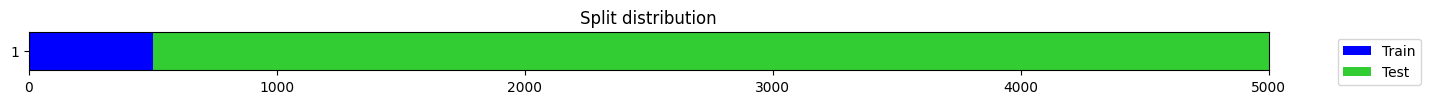

In [ ]:
check_data(ECG_X, ECG_y, ECG_splits)

In [ ]:
def plot_classes(X, y, n_series=20, separate=True):
    """
    Visualiza séries por classe do dataset UCR (ex: ECG5000).

    X: np.array com shape (n_amostras, n_canais, n_timestamps)
    y: labels correspondentes
    n_series: quantas séries por classe mostrar
    separate: se True, cria um subplot por classe; se False, plota todas juntas
    """
    classes = np.unique(y)

    if separate:
        fig, axes = plt.subplots(len(classes), 1, figsize=(12, 3*len(classes)), sharex=True)
        if len(classes) == 1:
            axes = [axes]  # garante lista
        for i, c in enumerate(classes):
            idx = np.where(y == c)[0][:n_series]
            for j in idx:
                axes[i].plot(X[j,0,:], alpha=0.4)
            axes[i].set_title(f"Classe {c} (n={len(idx)})")
        plt.tight_layout()
        plt.show()

    else:
        plt.figure(figsize=(12,6))
        for c in classes:
            idx = np.where(y == c)[0][:n_series]
            for j in idx:
                plt.plot(X[j,0,:], alpha=0.3, label=f"Classe {c}" if j==idx[0] else "")
        plt.legend()
        plt.title("Séries por classe (sobrepostas)")
        plt.show()

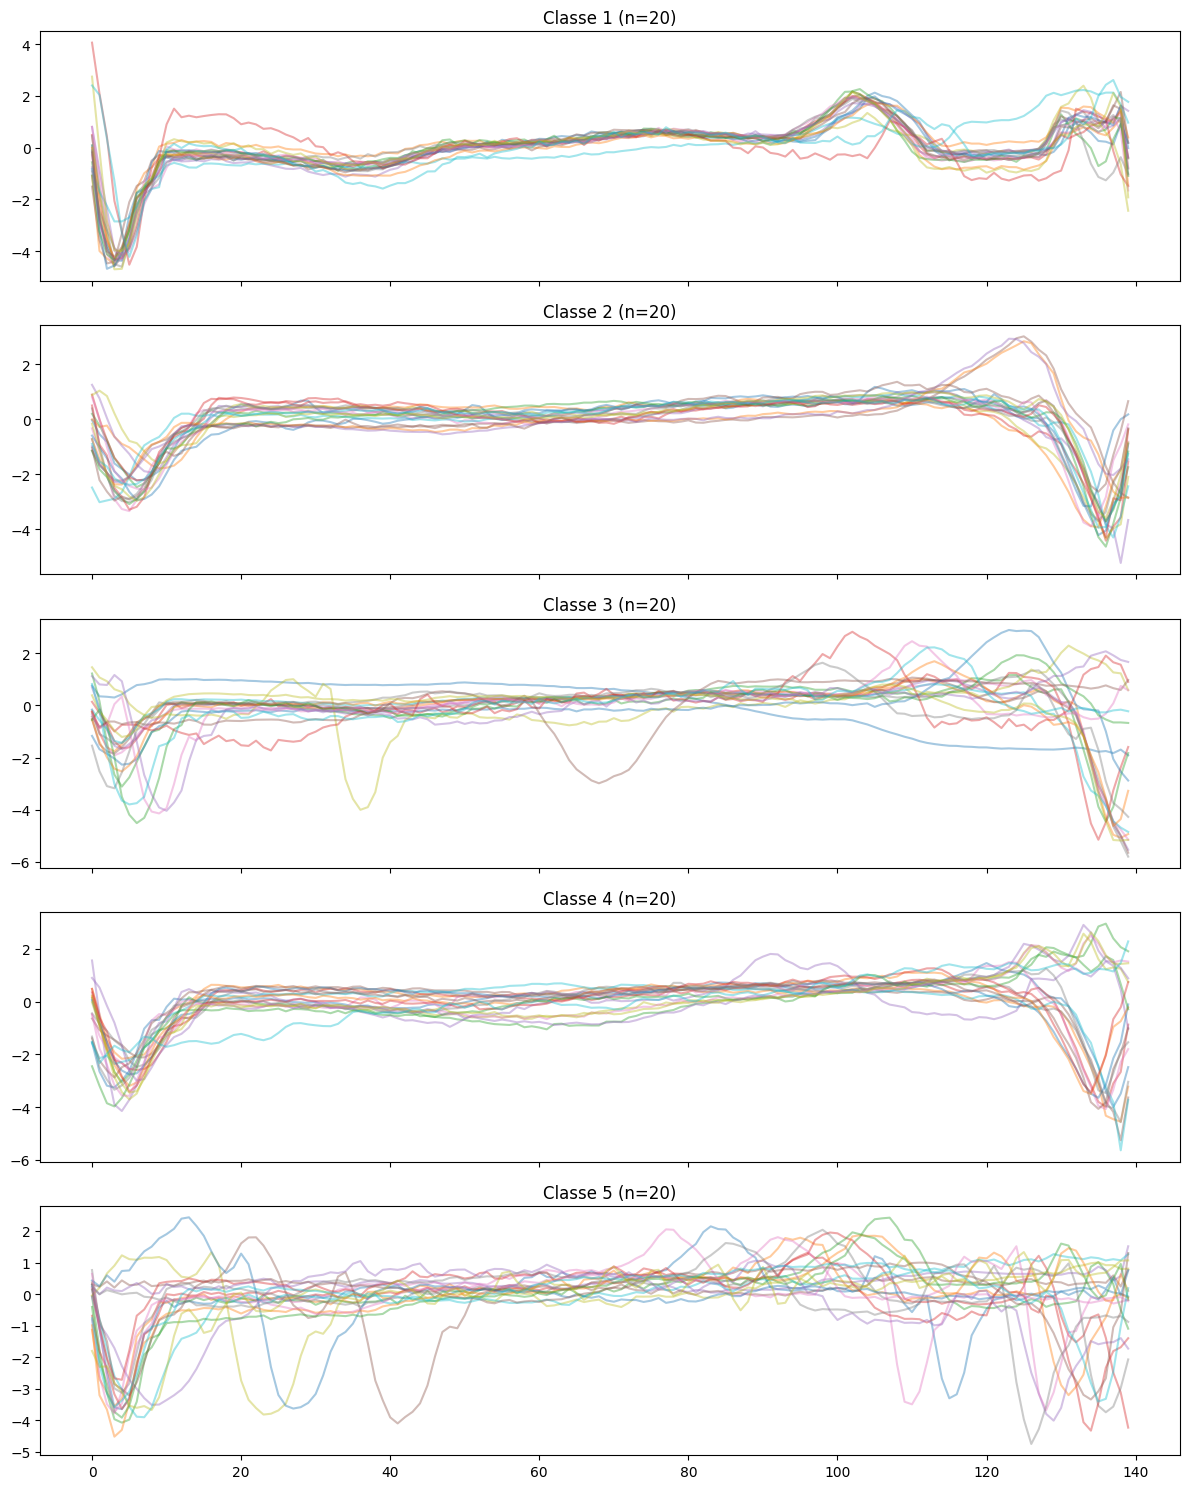

In [ ]:
# Plot em subplots (um gráfico por classe)
plot_classes(ECG_X, ECG_y, n_series=20, separate=True)

In [ ]:
from statsmodels.tsa.stattools import acf, pacf

# pega uma série qualquer (exemplo: primeira)
serie = ECG_X[0, 0, :]

lag_acf = acf(serie, nlags=40)
lag_pacf = pacf(serie, nlags=40)

print("ACF shape:", lag_acf.shape)
print("PACF shape:", lag_pacf.shape)

ACF shape: (41,)
PACF shape: (41,)


<Figure size 1200x400 with 0 Axes>

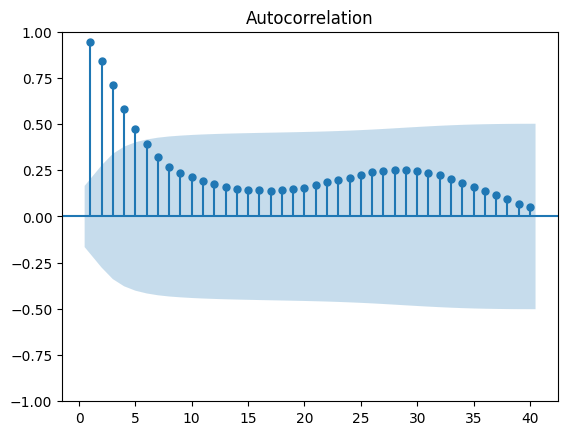

<Figure size 1200x400 with 0 Axes>

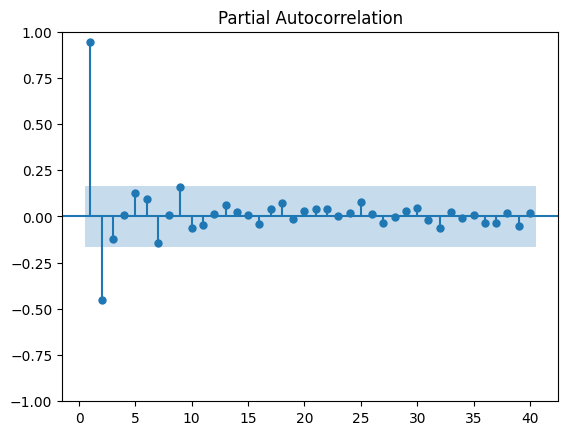

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.figure(figsize=(12,4))
plot_acf(serie, lags=40, zero=False)
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(serie, lags=40, zero=False, method='ywm')
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(serie)
print("p-value:", result[1])

if result[1] < 0.05:
    print("Série estacionária (rejeita H0)")
else:
    print("Série NÃO estacionária (não rejeita H0)")

p-value: 0.3479401378253919
Série NÃO estacionária (não rejeita H0)


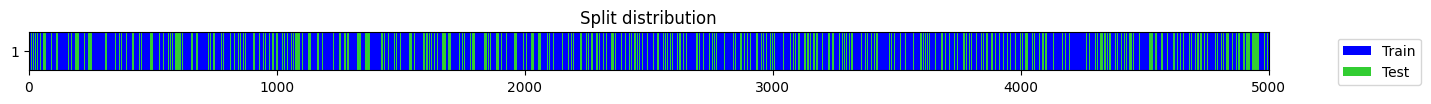

In [ ]:
#shuffle no ECG5000 é importante, pois ele vem ordenado por classe.
train_idx, val_idx = get_splits(
    ECG_y, valid_size=0.3, stratify=True, shuffle=True, random_state=42
)

splits = [train_idx, val_idx]

In [ ]:
ECG_X.shape

(5000, 1, 140)

In [ ]:
mrf = MiniRocketFeatures(ECG_X.shape[1], ECG_X.shape[2])
mrf.fit(ECG_X[splits[0]])

In [ ]:
ECG_X_rocket = get_minirocket_features(ECG_X, mrf, to_np=True)
ECG_X_rocket.shape

(5000, 9996, 1)

In [ ]:
X_train_feats = ECG_X_rocket[splits[0]]  # treino
X_val_feats   = ECG_X_rocket[splits[1]]  # validação

y_train = ECG_y[splits[0]]
y_val   = ECG_y[splits[1]]

# Ajustar shape para sklearn/XGBoost (remover dimensão de canal)
X_train_feats = X_train_feats.squeeze(-1)  # (n_train, n_features)
X_val_feats   = X_val_feats.squeeze(-1)    # (n_val, n_features)

In [ ]:
X_train_feats.shape

(3500, 9996)

In [ ]:
X_val_feats.shape

(1500, 9996)

In [ ]:
y_train.shape

(3500,)

In [ ]:
y_val.shape

(1500,)

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
y_train = y_train.astype(int)
y_val   = y_val.astype(int)

y_train = y_train - 1
y_val   = y_val - 1

In [ ]:
# Inicializa o classificador
xgb_clf = XGBClassifier(
    objective='multi:softmax',  # classificação multi-classe
    num_class=len(np.unique(y_train)),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

# Treina
eval_set = [(X_train_feats, y_train), (X_val_feats, y_val)]
xgb_clf.fit(X_train_feats, y_train, eval_set=eval_set, verbose=True)

[0]	validation_0-mlogloss:0.98865	validation_1-mlogloss:1.01262
[1]	validation_0-mlogloss:0.69365	validation_1-mlogloss:0.73733
[2]	validation_0-mlogloss:0.50780	validation_1-mlogloss:0.56405
[3]	validation_0-mlogloss:0.38196	validation_1-mlogloss:0.45017
[4]	validation_0-mlogloss:0.29046	validation_1-mlogloss:0.37209
[5]	validation_0-mlogloss:0.22066	validation_1-mlogloss:0.31664
[6]	validation_0-mlogloss:0.17134	validation_1-mlogloss:0.27542
[7]	validation_0-mlogloss:0.13406	validation_1-mlogloss:0.24454
[8]	validation_0-mlogloss:0.10537	validation_1-mlogloss:0.22274
[9]	validation_0-mlogloss:0.08264	validation_1-mlogloss:0.20764
[10]	validation_0-mlogloss:0.06596	validation_1-mlogloss:0.19696
[11]	validation_0-mlogloss:0.05233	validation_1-mlogloss:0.18882
[12]	validation_0-mlogloss:0.04263	validation_1-mlogloss:0.18305
[13]	validation_0-mlogloss:0.03474	validation_1-mlogloss:0.17949
[14]	validation_0-mlogloss:0.02890	validation_1-mlogloss:0.17777
[15]	validation_0-mlogloss:0.02421	

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=5, ...)

In [ ]:
y_pred = xgb_clf.predict(X_val_feats)

In [ ]:
acc = accuracy_score(y_val, y_pred)
print("Accuracy Validação:", acc)

Accuracy Validação: 0.958


In [ ]:
print("\nClassification Report:\n", classification_report(y_val, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       876
           1       0.92      0.99      0.95       530
           2       0.93      0.48      0.64        29
           3       0.85      0.40      0.54        58
           4       1.00      0.14      0.25         7

    accuracy                           0.96      1500
   macro avg       0.94      0.60      0.67      1500
weighted avg       0.96      0.96      0.95      1500



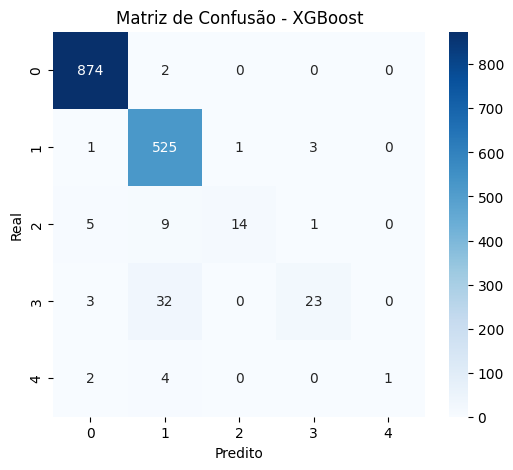

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - XGBoost')
plt.show()

Classes 0 e 1 → excelente, modelo domina essas classes.

Classes 2, 3 e 4 → recall baixo, f1 baixo → o modelo está errando bastante essas classes minoritárias.

Isso é típico em datasets desbalanceados (no ECG5000, as classes 2,3,4 têm poucas amostras).

##Conclusões:

MiniRocket + Classificador

Características principais:

MiniRocket gera features fixas e extremamente expressivas a partir da série temporal.

As features capturam padrões de diferentes escalas e convoluções rápidas, sem precisar modelar a série diretamente.

Depois, qualquer classificador/regressor (Ridge, XGBoost, RandomForest) aprende a partir dessas features.

Funciona bem com séries independentes, mesmo desbalanceadas, e não exige conhecimento profundo da série.

Vantagens:

Não precisa diferenciar a série → MiniRocket é robusto a tendências e offsets.

Normalização é opcional → a extração de features é baseada em convoluções e estatísticas internas.

Treino rápido → MiniRocket gera features e depois o classificador aprende rapidamente.

Fácil de combinar com diferentes classificadores.

Desvantagens:

Pode gerar muitas features, exigindo mais memória e processador.


Abordagens tradicionais de séries temporais

Exemplos: ARIMA, SARIMA...

Características:

Modelos tradicionais frequentemente usam:

Diferenciação (para remover tendência)

Ajustes manuais de parâmetros (AR, MA, lags)

Trabalham diretamente na série, ou seja, modelam dependência temporal explícita.

Impactos da diferenciação:

Diferenciação:

Necessária para séries não estacionárias, para que ARIMA/SARIMA funcione corretamente.

MiniRocket não precisa → ele extrai padrões “locais” da série.

Vantagens das abordagens tradicionais:

Boa interpretabilidade → coeficientes significam tendências, ciclos, autocorrelações.

Desvantagens:

Pré-processamento intenso (diferenciação, tuning de lags).

Treino mais sensível → performance cai se a série não for estacionária.

São mais usados para Forecast e não para regressão e classificação